In [1]:
import torch
from torchvision import datasets,transforms


In [2]:
print(torch.__version__)

2.9.0+cu126


In [3]:
transform = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [4]:
file_path = r'C:\Users\39608\Desktop\peoject\data\dogs_vs_cats_sample'

In [5]:
from torchvision.datasets import ImageFolder

In [6]:
train_dataset = ImageFolder(root = r'C:\Users\39608\Desktop\peoject\data\dogs_vs_cats_sample\train',transform = transform)
val_dataset = ImageFolder(root = r'C:\Users\39608\Desktop\peoject\data\dogs_vs_cats_sample\test1',transform = transform)

In [7]:
train_dataset

Dataset ImageFolder
    Number of datapoints: 1000
    Root location: C:\Users\39608\Desktop\peoject\data\dogs_vs_cats_sample\train
    StandardTransform
Transform: Compose(
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

In [8]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


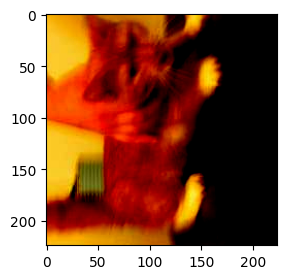

In [9]:
for i, j in train_dataset:
    plt.figure(figsize=(3,3))
    plt.imshow(i.numpy().transpose())
    plt.show()
    break

In [10]:
from torch.utils.data import DataLoader

In [11]:
train_dataload = DataLoader(
    dataset = train_dataset,
    batch_size= 8,
    shuffle=True
)

In [12]:
val_dataload = DataLoader(
    dataset = val_dataset,
    batch_size= 8,
    shuffle=False
)

In [13]:
for i ,j in train_dataload:
    print(i,j.shape)
    break

tensor([[[[-0.6000, -0.6314, -0.6627,  ..., -0.1373, -0.1216,  0.3490],
          [-0.6314, -0.6392, -0.6471,  ...,  0.4039, -0.1843,  0.6471],
          [-0.6314, -0.6392, -0.6471,  ...,  0.1451,  0.0588,  0.3569],
          ...,
          [ 0.6549,  0.6549,  0.6549,  ..., -0.5843, -0.6000, -0.6157],
          [ 0.6549,  0.6549,  0.6549,  ..., -0.6078, -0.6157, -0.6078],
          [ 0.6549,  0.6549,  0.6549,  ..., -0.6549, -0.6392, -0.5922]],

         [[-0.3882, -0.4196, -0.4510,  ...,  0.0667,  0.0745,  0.5451],
          [-0.4039, -0.4118, -0.4196,  ...,  0.5922,  0.0039,  0.8353],
          [-0.4039, -0.4118, -0.4196,  ...,  0.3333,  0.2471,  0.5216],
          ...,
          [ 0.7020,  0.7020,  0.7020,  ..., -0.6392, -0.6549, -0.6706],
          [ 0.7020,  0.7020,  0.7020,  ..., -0.6627, -0.6706, -0.6627],
          [ 0.7020,  0.7020,  0.7020,  ..., -0.7098, -0.6941, -0.6471]],

         [[-0.1529, -0.1843, -0.2157,  ...,  0.2784,  0.3098,  0.7804],
          [-0.1686, -0.1765, -

In [14]:
import torchvision

In [15]:
img_1,label_1 = next(iter(train_dataload))
print(img_1)

mean = [0.5,0.5,0.5]
std = [0.5,0.5,0.5]
img_batch = torchvision.utils.make_grid(img_1)
img_batch.shape
img_batch = img_batch.numpy().transpose((1,2,0))
img_batch = std*img_batch + mean

tensor([[[[ 0.4980,  0.5059,  0.5137,  ...,  0.4980,  0.4745,  0.4824],
          [ 0.4980,  0.5137,  0.5216,  ...,  0.4980,  0.4667,  0.4745],
          [ 0.4980,  0.5137,  0.5216,  ...,  0.4980,  0.4745,  0.4667],
          ...,
          [ 0.3647,  0.3725,  0.3725,  ..., -0.2157, -0.1373, -0.1686],
          [ 0.3569,  0.3569,  0.3569,  ..., -0.2392, -0.2078, -0.2235],
          [ 0.3490,  0.3490,  0.3490,  ..., -0.2314, -0.2471, -0.2471]],

         [[ 0.4353,  0.4431,  0.4510,  ...,  0.4745,  0.4510,  0.4588],
          [ 0.4118,  0.4275,  0.4353,  ...,  0.4745,  0.4431,  0.4510],
          [ 0.4118,  0.4275,  0.4353,  ...,  0.4745,  0.4510,  0.4431],
          ...,
          [ 0.3412,  0.3490,  0.3490,  ..., -0.4275, -0.3490, -0.3804],
          [ 0.3333,  0.3333,  0.3333,  ..., -0.4510, -0.4196, -0.4353],
          [ 0.3255,  0.3255,  0.3255,  ..., -0.4431, -0.4588, -0.4588]],

         [[ 0.2706,  0.2784,  0.2863,  ...,  0.3255,  0.3020,  0.3098],
          [ 0.2392,  0.2549,  

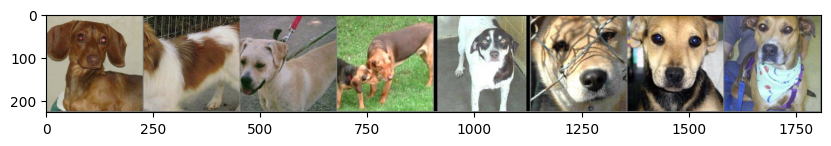

In [16]:
plt.figure(figsize=(10,10))
plt.imshow(img_batch)
plt.show()

In [17]:
# pth_path = r'models\vgg16-397923af.pth'

In [18]:
# vgg_model = torch.load(pth_path)

In [19]:
from torchvision import models

In [20]:
# print(vgg_model)    

In [21]:
model = models.vgg16(weights=None)

# print(vgg_model)

model.load_state_dict(torch.load(r'models\vgg16-397923af.pth'))
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [22]:
for param in model.parameters():
    param.requires_grad = False


In [23]:
model.classifier = torch.nn.Sequential(
    torch.nn.Linear(25088, 4096),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=0.5),
    
    torch.nn.Linear(4096, 4096),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=0.5),
    
    torch.nn.Linear(4096, 2),
)

In [24]:
for index, param in enumerate(model.classifier.parameters()):
    print(index, param.shape)

0 torch.Size([4096, 25088])
1 torch.Size([4096])
2 torch.Size([4096, 4096])
3 torch.Size([4096])
4 torch.Size([2, 4096])
5 torch.Size([2])


In [25]:
for index, param in enumerate(model.classifier.parameters()):
    if index == 4 or index == 5:
        param.requires_grad = True

In [26]:
from torchsummary import summary

In [27]:
summary(model, input_size = (3,224,224),device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [28]:
import torchmetrics,torchkeras

In [29]:
vgg_model = torchkeras.KerasModel(
    model,
    loss_fn = torch.nn.CrossEntropyLoss(),
    optimizer = torch.optim.Adam(model.classifier.parameters()),
    metrics_dict = {'acc': torchmetrics.Accuracy(task='multiclass', num_classes=2)}
)

<<<<<< ⚡️ cuda is used >>>>>>


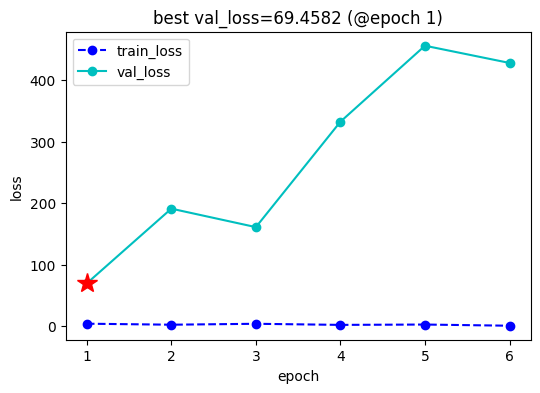

<<<<<< val_loss without improvement in 5 epoch,early stopping >>>>>> 



In [30]:
vgg_history = vgg_model.fit(
    train_data= train_dataload,
    val_data= val_dataload,
    epochs=10,
    plot=True,
    cpu=False
)


In [31]:
vgg_history

,epoch,train_loss,train_acc,lr,val_loss,val_acc
0,1,3.863214,0.885,0.001,69.458229,0.49
1,2,2.237522,0.939,0.001,190.964850,0.42
2,3,3.731337,0.945,0.001,160.916745,0.56
3,4,1.943031,0.966,0.001,332.372985,0.51
4,5,2.508597,0.978,0.001,455.940170,0.49
5,6,0.579882,0.991,0.001,427.928956,0.52


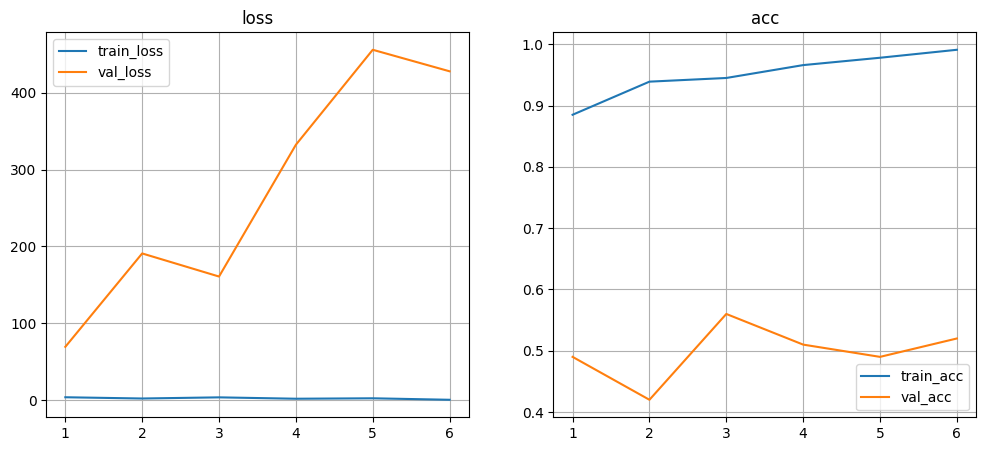

In [53]:
plt.figure(figsize = (12,5))
plt.subplot(121)
plt.plot(vgg_history['epoch'],vgg_history['train_loss'], label = 'train_loss')
plt.plot(vgg_history['epoch'],vgg_history['val_loss'], label = 'val_loss')
plt.xticks(vgg_history['epoch'])
plt.grid()
plt.legend()
plt.title('loss')

plt.subplot(122)
plt.plot(vgg_history['epoch'],vgg_history['train_acc'], label = 'train_acc')
plt.plot(vgg_history['epoch'],vgg_history['val_acc'], label = 'val_acc')
plt.xticks(vgg_history['epoch'])
plt.grid()
plt.legend()
plt.title('acc')

plt.show()

In [33]:
my_vgg = torch.load(r'models\my_vgg')

In [34]:
# my_vgg = models.vgg16(weights=None)

In [35]:
from torchvision.models import vgg16

In [36]:
my_vgg_model =  vgg16(weights=False)

d:\python\conda\envs\cv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [37]:
my_vgg_model.classifier = torch.nn.Sequential(
    torch.nn.Linear(25088, 4096),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=0.5),
    
    torch.nn.Linear(4096, 4096),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=0.5),
    
    torch.nn.Linear(4096, 2),
)

In [38]:
my_vgg_model.load_state_dict(my_vgg)

<All keys matched successfully>

In [39]:
transform

Compose(
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

In [40]:
test_img = ImageFolder(
    root = r'data\dogs_vs_cats_sample\test1',
    transform = transform  
)

In [41]:
test_img_loadr = DataLoader(
    dataset = test_img,
    batch_size=8
)

In [ ]:
img_1,label_1 = next(iter(test_img_loadr))

In [43]:
pred = my_vgg_model.forward(img_1)
pred = torch.nn.Softmax(dim=1)(pred)
pred = torch.argmax(pred,dim=1)

In [44]:
pred

tensor([1, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
img_1.numpy().shape

(8, 3, 224, 224)

In [46]:
img = torchvision.utils.make_grid(img_1)
img = img.cpu().numpy().transpose(1,2,0)

In [47]:
mean = [0.5,0.5,0.5]
std = [0.5,0.5,0.5]
img = img*std+mean
classes = ['cat','dog']

Pred Label: ['dog', 'cat', 'cat', 'cat', 'dog', 'cat', 'cat', 'cat']


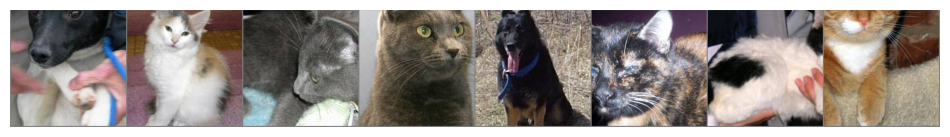

In [48]:
print("Pred Label:", [classes[i] for i in pred])
plt.figure(figsize=(12,6))
plt.imshow(img)
plt.axis('off')
plt.show()